# Real-only masked-frequency autoencoder pilot

This notebook performs a go/no-go experiment for frequency-domain anomaly detection:

1. Sample real training images only.
2. Convert each image to its full 2-D RGB log-magnitude FFT spectrum.
3. Hide either the low-frequency disk or its high-frequency complement.
4. Train a small convolutional autoencoder to reconstruct the complete spectrum.
5. Freeze the model and calibrate score scales using held-out real training images only.
6. Compare real and AI anomaly-score distributions on SID and CompEval under clean, JPEG, blur, and combined degradation.
7. Report directional AUC (AI = 1), stratified bootstrap confidence intervals, effect sizes, histograms, and a conservative go/no-go summary.

This is a lightweight hypothesis test inspired by masked spectral learning, not an exact reproduction of the any-resolution spectral-learning architecture. It deliberately preserves the full 2-D spectrum rather than reducing it to a radial average, so directional and localized spectral structure remain available.

Important: SID and CompEval labels are used only after scores have been produced, to measure AUC. They do not fit the autoencoder or calibrate the combined score. Keep DALL-E3 untouched until you have selected the method.

In [1]:
# If your environment is missing a dependency, uncomment and run:
# %pip install torch pandas numpy pillow matplotlib scikit-learn tqdm

In [1]:
import os

# Set this before importing NumPy, scikit-learn, or PyTorch. PyTorch may
# load libgomp, which is incompatible with MKL's INTEL threading layer.
os.environ["MKL_THREADING_LAYER"] = "GNU"

from pathlib import Path
from io import BytesIO
import copy
import json
import math
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageOps
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


# ---------------------------
# Paths
# ---------------------------
TRAIN_REAL_DIR = Path("/home/utakata/LLMs/techjam2026/SID/real")
SID_REAL_DIR = Path("/home/utakata/LLMs/techjam2026/SID/test/real")
SID_AI_DIR = Path("/home/utakata/LLMs/techjam2026/SID/test/full_synthetic")

COMPEVAL_REAL_DIR = Path("data/com/val/real")
COMPEVAL_AI_DIR = Path("data/com/val/ai")

OUTPUT_DIR = Path("masked_frequency_experiment")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------
# Experiment size
# ---------------------------
SEED = 42
QUICK_RUN = False

IMAGE_SIZE = 224
MAX_TRAIN_REAL = 20_000
REAL_CALIBRATION_FRACTION = 0.10
NUM_EVAL_PER_CLASS = 1_000
SPECTRUM_STATS_MAX_IMAGES = 4_000

EPOCHS = 3
BATCH_SIZE = 32
# Jupyter on Python 3.14 commonly uses a fork-server process context.
# Keep this at zero unless DataLoader multiprocessing is known to work
# with the MKL/OpenMP libraries in your environment.
NUM_WORKERS = 0
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 5.0

# Radius is measured from the centered FFT origin in pixels.
# Try one fixed value first. Sweeping it repeatedly on labeled test data causes leakage.
MASK_RADIUS_PIXELS = 32

VISIBLE_RECON_WEIGHT = 0.05
FULL_RECON_WEIGHT = 0.05
LATENT_CONSISTENCY_WEIGHT = 0.05

BOOTSTRAP_REPEATS = 1_000

VARIANTS = [
    "clean",
    "jpeg_q60",
    "jpeg_q30",
    "blur_sigma1",
    "blur_sigma2",
    "blur2_jpeg30",
]

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

TRAIN_MODEL = True
CHECKPOINT_PATH = OUTPUT_DIR / "masked_frequency_autoencoder.pt"

if QUICK_RUN:
    MAX_TRAIN_REAL = 2_000
    NUM_EVAL_PER_CLASS = 250
    SPECTRUM_STATS_MAX_IMAGES = 1_000
    EPOCHS = 2
    BOOTSTRAP_REPEATS = 200

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

print(f"Device: {DEVICE}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Device: cuda
AMP enabled: True
Output directory: /home/utakata/LLMs/techjam/masked_frequency_experiment


## Reproducibility, image loading, and matched degradations

Every condition uses the same sampled real and AI file paths. Images are first converted safely to RGB and resized to 224 × 224; the named degradation is then applied. TIFF is excluded here to avoid mixing the earlier truncated-TIFF issue into this experiment.

In [2]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Fixed-size convolutions benefit from this. Set False if strict bitwise
    # reproducibility across CUDA runs matters more than speed.
    torch.backends.cudnn.benchmark = True


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


seed_everything(SEED)


def list_image_paths(root):
    root = Path(root)
    if not root.is_dir():
        raise FileNotFoundError(f"Directory does not exist: {root}")

    paths = sorted(
        path
        for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    if not paths:
        raise RuntimeError(f"No supported images found in: {root}")
    return paths


def load_rgb_image(path):
    with Image.open(path) as source:
        source = ImageOps.exif_transpose(source)
        has_transparency = (
            source.mode in {"RGBA", "LA"}
            or (source.mode == "P" and "transparency" in source.info)
        )

        if has_transparency:
            rgba = source.convert("RGBA")
            background = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
            image = Image.alpha_composite(background, rgba).convert("RGB")
        else:
            image = source.convert("RGB")

        image.load()
        return image.copy()


def is_readable_image(path):
    try:
        load_rgb_image(path)
        return True
    except Exception:
        return False


def sample_readable_paths(root, count, rng, description):
    candidates = list_image_paths(root)
    rng.shuffle(candidates)

    target = len(candidates) if count is None else min(count, len(candidates))
    selected = []

    for path in tqdm(candidates, desc=description):
        if is_readable_image(path):
            selected.append(path)
        if len(selected) == target:
            break

    if count is not None and len(selected) < count:
        warnings.warn(
            f"Requested {count} readable images from {root}, "
            f"but found only {len(selected)}."
        )

    if not selected:
        raise RuntimeError(f"No readable images found in: {root}")

    return selected


def jpeg_roundtrip(image, quality):
    buffer = BytesIO()
    image.save(
        buffer,
        format="JPEG",
        quality=int(quality),
        subsampling=2,
        optimize=False,
    )
    buffer.seek(0)
    with Image.open(buffer) as decoded:
        decoded.load()
        return decoded.convert("RGB").copy()


def apply_variant(image, variant):
    image = image.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        resample=Image.Resampling.LANCZOS,
    )

    if variant == "clean":
        return image

    if variant == "jpeg_q60":
        return jpeg_roundtrip(image, 60)

    if variant == "jpeg_q30":
        return jpeg_roundtrip(image, 30)

    if variant == "blur_sigma1":
        return image.filter(ImageFilter.GaussianBlur(radius=1.0))

    if variant == "blur_sigma2":
        return image.filter(ImageFilter.GaussianBlur(radius=2.0))

    if variant == "blur2_jpeg30":
        blurred = image.filter(ImageFilter.GaussianBlur(radius=2.0))
        return jpeg_roundtrip(blurred, 30)

    raise ValueError(f"Unknown variant: {variant}")


def pil_to_float_tensor(image):
    array = np.asarray(image, dtype=np.float32)
    return torch.from_numpy(array).permute(2, 0, 1).contiguous() / 255.0

## Select disjoint real-only fitting/calibration sets and evaluation samples

The real calibration split is held out from autoencoder fitting. It estimates only the mean and standard deviation of each anomaly-score component; no real/AI label comparison is used for calibration.

In [3]:
path_rng = random.Random(SEED)

all_selected_train_real = sample_readable_paths(
    TRAIN_REAL_DIR,
    MAX_TRAIN_REAL,
    path_rng,
    "Selecting readable real training images",
)
path_rng.shuffle(all_selected_train_real)

num_calibration = max(
    1,
    int(round(len(all_selected_train_real) * REAL_CALIBRATION_FRACTION)),
)
calibration_real_paths = all_selected_train_real[:num_calibration]
fit_real_paths = all_selected_train_real[num_calibration:]

sid_real_paths = sample_readable_paths(
    SID_REAL_DIR,
    NUM_EVAL_PER_CLASS,
    path_rng,
    "Selecting SID real images",
)
sid_ai_paths = sample_readable_paths(
    SID_AI_DIR,
    NUM_EVAL_PER_CLASS,
    path_rng,
    "Selecting SID AI images",
)
compeval_real_paths = sample_readable_paths(
    COMPEVAL_REAL_DIR,
    NUM_EVAL_PER_CLASS,
    path_rng,
    "Selecting CompEval real images",
)
compeval_ai_paths = sample_readable_paths(
    COMPEVAL_AI_DIR,
    NUM_EVAL_PER_CLASS,
    path_rng,
    "Selecting CompEval AI images",
)

fit_set = {path.resolve() for path in fit_real_paths}
calibration_set = {path.resolve() for path in calibration_real_paths}
assert fit_set.isdisjoint(calibration_set)

print(f"Real-only autoencoder fit: {len(fit_real_paths):,}")
print(f"Real-only score calibration: {len(calibration_real_paths):,}")
print(
    "SID evaluation: "
    f"{len(sid_real_paths):,} real + {len(sid_ai_paths):,} AI"
)
print(
    "CompEval evaluation: "
    f"{len(compeval_real_paths):,} real + {len(compeval_ai_paths):,} AI"
)

manifest_rows = []
for split_name, paths, label in [
    ("fit_real", fit_real_paths, 0),
    ("calibration_real", calibration_real_paths, 0),
    ("sid_real", sid_real_paths, 0),
    ("sid_ai", sid_ai_paths, 1),
    ("compeval_real", compeval_real_paths, 0),
    ("compeval_ai", compeval_ai_paths, 1),
]:
    manifest_rows.extend(
        {
            "split": split_name,
            "label": label,
            "path": str(path.resolve()),
        }
        for path in paths
    )

sample_manifest = pd.DataFrame(manifest_rows)
sample_manifest.to_csv(OUTPUT_DIR / "sample_manifest.csv", index=False)
sample_manifest.groupby(["split", "label"]).size().rename("count").to_frame()

Selecting readable real training images:   0%|          | 0/50000 [00:00<?, ?it/s]

Selecting SID real images:   0%|          | 0/20000 [00:00<?, ?it/s]

Selecting SID AI images:   0%|          | 0/20000 [00:00<?, ?it/s]

Selecting CompEval real images:   0%|          | 0/14070 [00:00<?, ?it/s]

Selecting CompEval AI images:   0%|          | 0/20000 [00:00<?, ?it/s]

Real-only autoencoder fit: 18,000
Real-only score calibration: 2,000
SID evaluation: 1,000 real + 1,000 AI
CompEval evaluation: 1,000 real + 1,000 AI


,,count
split,label,
calibration_real,0,2000
compeval_ai,1,1000
compeval_real,0,1000
fit_real,0,18000
sid_ai,1,1000
sid_real,0,1000


## Batched FFT representation

The model sees the centered, full two-dimensional RGB log-magnitude spectrum. Before the FFT, each channel's spatial mean is removed and a Hann window reduces boundary discontinuities. Channel-wise normalization statistics are estimated from real fitting images only.

Unlike a radial spectrum, this representation retains orientation, anisotropy, and localized peaks.

In [4]:
class RGBPathDataset(Dataset):
    def __init__(self, paths, labels=None, variant="clean"):
        self.paths = [Path(path) for path in paths]
        self.labels = labels
        self.variant = variant

        if labels is not None and len(labels) != len(paths):
            raise ValueError("labels and paths must have equal length")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = load_rgb_image(path)
        image = apply_variant(image, self.variant)
        tensor = pil_to_float_tensor(image)

        if self.labels is None:
            return tensor

        return tensor, int(self.labels[index]), str(path)


def make_loader(
    dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    persistent=False,
):
    generator = torch.Generator()
    generator.manual_seed(SEED)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        worker_init_fn=seed_worker,
        generator=generator,
        persistent_workers=persistent and NUM_WORKERS > 0,
        drop_last=False,
    )


_HANN_CACHE = {}


def hann_window_2d(height, width, device, dtype):
    key = (height, width, str(device), dtype)
    if key not in _HANN_CACHE:
        window_y = torch.hann_window(
            height,
            periodic=False,
            device=device,
            dtype=dtype,
        )
        window_x = torch.hann_window(
            width,
            periodic=False,
            device=device,
            dtype=dtype,
        )
        _HANN_CACHE[key] = window_y[:, None] * window_x[None, :]
    return _HANN_CACHE[key]


def log_magnitude_spectrum(images):
    # FFT stays in float32 even when the convolutional model uses AMP.
    images = images.float()
    images = images - images.mean(dim=(-2, -1), keepdim=True)

    height, width = images.shape[-2:]
    window = hann_window_2d(
        height,
        width,
        images.device,
        images.dtype,
    )
    windowed = images * window[None, None, :, :]

    spectrum = torch.fft.fft2(windowed, norm="ortho")
    spectrum = torch.fft.fftshift(spectrum, dim=(-2, -1))
    return torch.log1p(torch.abs(spectrum))


@torch.inference_mode()
def estimate_spectrum_statistics(loader, max_images):
    channel_sum = torch.zeros(3, dtype=torch.float64)
    channel_square_sum = torch.zeros(3, dtype=torch.float64)
    scalar_count = 0
    images_seen = 0

    for images in tqdm(loader, desc="Estimating real-spectrum statistics"):
        remaining = max_images - images_seen
        if remaining <= 0:
            break

        images = images[:remaining].to(DEVICE, non_blocking=True)
        spectrum = log_magnitude_spectrum(images)

        channel_sum += spectrum.sum(
            dim=(0, 2, 3)
        ).double().cpu()
        channel_square_sum += spectrum.square().sum(
            dim=(0, 2, 3)
        ).double().cpu()

        batch_count = (
            spectrum.shape[0]
            * spectrum.shape[2]
            * spectrum.shape[3]
        )
        scalar_count += batch_count
        images_seen += spectrum.shape[0]

    mean = channel_sum / scalar_count
    variance = channel_square_sum / scalar_count - mean.square()
    std = variance.clamp_min(1e-8).sqrt()

    return (
        mean.float().view(1, 3, 1, 1),
        std.float().view(1, 3, 1, 1),
        images_seen,
    )


fit_dataset = RGBPathDataset(fit_real_paths, variant="clean")
fit_loader = make_loader(
    fit_dataset,
    shuffle=True,
    persistent=True,
)
stats_loader = make_loader(
    fit_dataset,
    shuffle=False,
    persistent=False,
)

SPECTRUM_MEAN, SPECTRUM_STD, stats_images_seen = (
    estimate_spectrum_statistics(
        stats_loader,
        min(SPECTRUM_STATS_MAX_IMAGES, len(fit_dataset)),
    )
)

print(f"Spectrum statistics estimated from {stats_images_seen:,} real images")
print("Channel means:", SPECTRUM_MEAN.flatten().tolist())
print("Channel stds: ", SPECTRUM_STD.flatten().tolist())


def normalize_spectrum(spectrum):
    mean = SPECTRUM_MEAN.to(
        device=spectrum.device,
        dtype=spectrum.dtype,
    )
    std = SPECTRUM_STD.to(
        device=spectrum.device,
        dtype=spectrum.dtype,
    )
    return (spectrum - mean) / std

Estimating real-spectrum statistics:   0%|          | 0/563 [00:00<?, ?it/s]

Spectrum statistics estimated from 4,000 real images
Channel means: [0.026240922510623932, 0.025700030848383904, 0.025103813037276268]
Channel stds:  [0.05612381547689438, 0.054230861365795135, 0.05373861640691757]


## Masked-spectrum autoencoder

For each training image, the network randomly receives either:

- only the low-frequency disk, or
- only the high-frequency complement.

Masked bins are replaced by the real-training mean after normalization (zero), and a fourth input channel explicitly identifies visible bins. The principal loss is reconstruction of the missing region. A small full-spectrum reconstruction term exposes the encoder to the full view, and a weak real-only latent-consistency term encourages the full and masked views of a real image to agree without using AI examples.

In [5]:
def group_count(channels):
    for groups in (8, 4, 2, 1):
        if channels % groups == 0:
            return groups
    return 1


class ConvNormAct(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(group_count(out_channels), out_channels),
            nn.SiLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.GroupNorm(group_count(out_channels), out_channels),
            nn.SiLU(inplace=True),
        )

    def forward(self, inputs):
        return self.block(inputs)


class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = ConvNormAct(in_channels, out_channels)

    def forward(self, inputs):
        inputs = F.interpolate(
            inputs,
            scale_factor=2.0,
            mode="bilinear",
            align_corners=False,
        )
        return self.block(inputs)


class MaskedSpectrumAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = ConvNormAct(4, 32)
        self.down1 = ConvNormAct(32, 64, stride=2)
        self.down2 = ConvNormAct(64, 96, stride=2)
        self.down3 = ConvNormAct(96, 160, stride=2)
        self.down4 = ConvNormAct(160, 256, stride=2)
        self.bottleneck = ConvNormAct(256, 256)

        self.up1 = UpBlock(256, 160)
        self.up2 = UpBlock(160, 96)
        self.up3 = UpBlock(96, 64)
        self.up4 = UpBlock(64, 32)
        self.output = nn.Conv2d(32, 3, kernel_size=1)

    def encode(self, full_spectrum, visible_mask):
        masked_spectrum = full_spectrum * visible_mask
        inputs = torch.cat([masked_spectrum, visible_mask], dim=1)

        features = self.stem(inputs)
        features = self.down1(features)
        features = self.down2(features)
        features = self.down3(features)
        features = self.down4(features)
        features = self.bottleneck(features)

        latent = F.adaptive_avg_pool2d(features, 1).flatten(1)
        return features, latent

    def decode(self, features):
        features = self.up1(features)
        features = self.up2(features)
        features = self.up3(features)
        features = self.up4(features)
        return self.output(features)

    def forward(self, full_spectrum, visible_mask):
        features, latent = self.encode(full_spectrum, visible_mask)
        reconstruction = self.decode(features)
        return reconstruction, latent


def radial_visibility_masks(
    batch_size,
    height,
    width,
    radius_pixels,
    device,
    dtype,
):
    y = torch.arange(height, device=device, dtype=dtype)
    x = torch.arange(width, device=device, dtype=dtype)
    y = y - (height - 1) / 2.0
    x = x - (width - 1) / 2.0

    radius = torch.sqrt(y[:, None].square() + x[None, :].square())
    low = (radius <= radius_pixels).to(dtype)
    low = low.view(1, 1, height, width)
    high = 1.0 - low

    return (
        low.expand(batch_size, -1, -1, -1),
        high.expand(batch_size, -1, -1, -1),
    )


def random_low_or_high_mask(spectrum):
    batch_size, _, height, width = spectrum.shape
    low, high = radial_visibility_masks(
        batch_size,
        height,
        width,
        MASK_RADIUS_PIXELS,
        spectrum.device,
        spectrum.dtype,
    )
    choose_low = (
        torch.rand(batch_size, 1, 1, 1, device=spectrum.device)
        < 0.5
    )
    return torch.where(choose_low, low, high)


def masked_reconstruction_loss(
    prediction,
    target,
    visible_mask,
):
    element_loss = F.smooth_l1_loss(
        prediction,
        target,
        reduction="none",
        beta=0.1,
    )
    missing_mask = 1.0 - visible_mask
    channels = target.shape[1]

    missing_denominator = (
        missing_mask.sum() * channels
    ).clamp_min(1.0)
    visible_denominator = (
        visible_mask.sum() * channels
    ).clamp_min(1.0)

    missing_loss = (
        element_loss * missing_mask
    ).sum() / missing_denominator
    visible_loss = (
        element_loss * visible_mask
    ).sum() / visible_denominator

    total = (
        missing_loss
        + VISIBLE_RECON_WEIGHT * visible_loss
    )
    return total, missing_loss, visible_loss

## Train on real images only

The checkpoint is selected using masked reconstruction loss on the held-out real calibration split. That split is later reused only for label-free score scaling. No AI image enters this stage.

Training:   0%|          | 0/563 [00:00<?, ?it/s]

Real-only validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 01/3 | train total=0.2037, missing=0.1851, latent=0.0025 | real-val total=0.5858, missing=0.5502 | 249.5s


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Real-only validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 02/3 | train total=0.1871, missing=0.1708, latent=0.0012 | real-val total=0.5780, missing=0.5432 | 254.8s


Training:   0%|          | 0/563 [00:00<?, ?it/s]

Real-only validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 03/3 | train total=0.1866, missing=0.1707, latent=0.0012 | real-val total=0.5734, missing=0.5388 | 245.9s
Saved checkpoint: masked_frequency_experiment/masked_frequency_autoencoder.pt


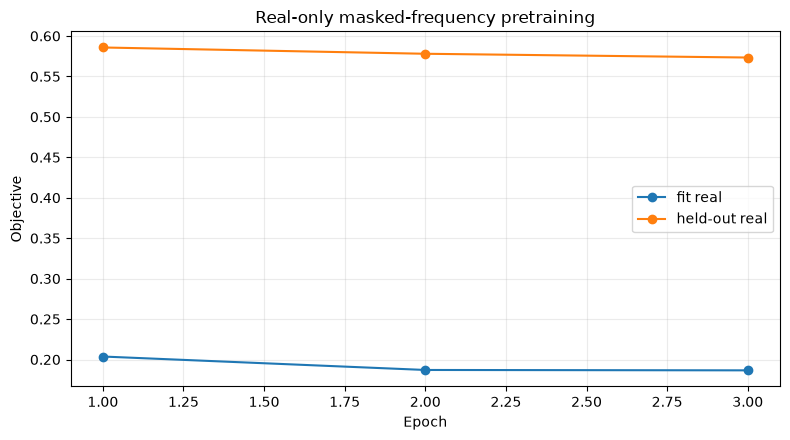

In [6]:
def prepare_normalized_spectrum(images):
    images = images.to(DEVICE, non_blocking=True)
    # CUDA FFT does not reliably support every half-precision size.
    with torch.autocast(
        device_type=DEVICE.type,
        enabled=False,
    ):
        spectrum = log_magnitude_spectrum(images)
        spectrum = normalize_spectrum(spectrum)
    return spectrum


def full_training_objective(model, spectrum, visible_mask):
    batch_size, _, height, width = spectrum.shape
    all_visible = torch.ones(
        batch_size,
        1,
        height,
        width,
        device=spectrum.device,
        dtype=spectrum.dtype,
    )

    masked_prediction, masked_latent = model(
        spectrum,
        visible_mask,
    )
    full_prediction, full_latent = model(
        spectrum,
        all_visible,
    )

    masked_total, missing_loss, visible_loss = (
        masked_reconstruction_loss(
            masked_prediction,
            spectrum,
            visible_mask,
        )
    )
    full_reconstruction_loss = F.smooth_l1_loss(
        full_prediction,
        spectrum,
        beta=0.1,
    )
    latent_consistency_loss = (
        1.0
        - F.cosine_similarity(
            masked_latent,
            full_latent,
            dim=1,
        )
    ).mean()

    total = (
        masked_total
        + FULL_RECON_WEIGHT * full_reconstruction_loss
        + LATENT_CONSISTENCY_WEIGHT * latent_consistency_loss
    )

    components = {
        "total": total,
        "missing": missing_loss,
        "visible": visible_loss,
        "full": full_reconstruction_loss,
        "latent": latent_consistency_loss,
    }
    return components


def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    totals = {
        key: 0.0
        for key in ("total", "missing", "visible", "full", "latent")
    }
    examples = 0

    for images in tqdm(loader, desc="Training", leave=False):
        spectrum = prepare_normalized_spectrum(images)
        visible_mask = random_low_or_high_mask(spectrum)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=AMP_ENABLED,
        ):
            components = full_training_objective(
                model,
                spectrum,
                visible_mask,
            )

        scaler.scale(components["total"]).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM,
        )
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.shape[0]
        examples += batch_size
        for key in totals:
            totals[key] += (
                float(components[key].detach()) * batch_size
            )

    return {
        key: value / examples
        for key, value in totals.items()
    }


@torch.inference_mode()
def validate_on_real(model, loader):
    model.eval()
    totals = {
        key: 0.0
        for key in ("total", "missing", "visible", "full", "latent")
    }
    examples = 0

    for images in tqdm(
        loader,
        desc="Real-only validation",
        leave=False,
    ):
        spectrum = prepare_normalized_spectrum(images)
        batch_size, _, height, width = spectrum.shape
        low, high = radial_visibility_masks(
            batch_size,
            height,
            width,
            MASK_RADIUS_PIXELS,
            spectrum.device,
            spectrum.dtype,
        )

        condition_components = []
        for visible_mask in (low, high):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=AMP_ENABLED,
            ):
                condition_components.append(
                    full_training_objective(
                        model,
                        spectrum,
                        visible_mask,
                    )
                )

        examples += batch_size
        for key in totals:
            batch_value = 0.5 * (
                condition_components[0][key]
                + condition_components[1][key]
            )
            totals[key] += float(batch_value) * batch_size

    return {
        key: value / examples
        for key, value in totals.items()
    }


calibration_dataset = RGBPathDataset(
    calibration_real_paths,
    variant="clean",
)
calibration_loader = make_loader(
    calibration_dataset,
    shuffle=False,
    persistent=False,
)

model = MaskedSpectrumAutoencoder().to(DEVICE)
history = []

if TRAIN_MODEL:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=AMP_ENABLED,
    )

    best_validation_loss = math.inf
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        start_time = time.time()
        train_metrics = train_one_epoch(
            model,
            fit_loader,
            optimizer,
            scaler,
        )
        validation_metrics = validate_on_real(
            model,
            calibration_loader,
        )

        row = {
            "epoch": epoch,
            "seconds": time.time() - start_time,
            **{
                f"train_{key}": value
                for key, value in train_metrics.items()
            },
            **{
                f"real_validation_{key}": value
                for key, value in validation_metrics.items()
            },
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train total={train_metrics['total']:.4f}, "
            f"missing={train_metrics['missing']:.4f}, "
            f"latent={train_metrics['latent']:.4f} | "
            f"real-val total={validation_metrics['total']:.4f}, "
            f"missing={validation_metrics['missing']:.4f} | "
            f"{row['seconds']:.1f}s"
        )

        if validation_metrics["total"] < best_validation_loss:
            best_validation_loss = validation_metrics["total"]
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    model.load_state_dict(best_state)

    checkpoint = {
        "model_state": best_state,
        "spectrum_mean": SPECTRUM_MEAN.cpu(),
        "spectrum_std": SPECTRUM_STD.cpu(),
        "image_size": IMAGE_SIZE,
        "mask_radius_pixels": MASK_RADIUS_PIXELS,
        "seed": SEED,
        "fit_real_paths": [str(path) for path in fit_real_paths],
        "calibration_real_paths": [
            str(path) for path in calibration_real_paths
        ],
    }
    torch.save(checkpoint, CHECKPOINT_PATH)
    pd.DataFrame(history).to_csv(
        OUTPUT_DIR / "training_history.csv",
        index=False,
    )
    print(f"Saved checkpoint: {CHECKPOINT_PATH}")
else:
    if not CHECKPOINT_PATH.is_file():
        raise FileNotFoundError(
            f"TRAIN_MODEL=False, but checkpoint is missing: "
            f"{CHECKPOINT_PATH}"
        )

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location="cpu",
        weights_only=False,
    )
    if checkpoint["image_size"] != IMAGE_SIZE:
        raise ValueError("Checkpoint IMAGE_SIZE does not match config")
    if checkpoint["mask_radius_pixels"] != MASK_RADIUS_PIXELS:
        raise ValueError(
            "Checkpoint MASK_RADIUS_PIXELS does not match config"
        )

    SPECTRUM_MEAN = checkpoint["spectrum_mean"]
    SPECTRUM_STD = checkpoint["spectrum_std"]
    model.load_state_dict(checkpoint["model_state"])

model = model.to(DEVICE).eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)

if history:
    history_frame = pd.DataFrame(history)
    fig, axis = plt.subplots(figsize=(8, 4.5))
    axis.plot(
        history_frame["epoch"],
        history_frame["train_total"],
        marker="o",
        label="fit real",
    )
    axis.plot(
        history_frame["epoch"],
        history_frame["real_validation_total"],
        marker="o",
        label="held-out real",
    )
    axis.set(
        xlabel="Epoch",
        ylabel="Objective",
        title="Real-only masked-frequency pretraining",
    )
    axis.grid(alpha=0.25)
    axis.legend()
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / "training_curve.png",
        dpi=180,
    )
    plt.show()

## Freeze the model and define anomaly scores

For each image:

- Reconstruction error is the mean of low-to-high and high-to-low missing-region errors.
- Latent anomaly is one minus the mean cosine similarity among full/low, full/high, and low/high latent vectors.
- Combined anomaly is the equally weighted average of the two component z-scores, using means and standard deviations from held-out real training images only.

Higher scores are fixed in advance to mean “more anomalous / more likely AI.” Directional AUC below 0.5 is therefore not silently flipped.

In [7]:
def per_sample_region_mae(
    prediction,
    target,
    region_mask,
):
    absolute_error = (prediction - target).abs()
    channels = target.shape[1]
    numerator = (
        absolute_error * region_mask
    ).sum(dim=(1, 2, 3))
    denominator = (
        region_mask.sum(dim=(1, 2, 3)) * channels
    ).clamp_min(1.0)
    return numerator / denominator


@torch.inference_mode()
def anomaly_scores_for_spectrum(spectrum):
    model.eval()
    batch_size, _, height, width = spectrum.shape
    low, high = radial_visibility_masks(
        batch_size,
        height,
        width,
        MASK_RADIUS_PIXELS,
        spectrum.device,
        spectrum.dtype,
    )
    full = torch.ones_like(low)

    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=AMP_ENABLED,
    ):
        low_prediction, low_latent = model(spectrum, low)
        high_prediction, high_latent = model(spectrum, high)
        _, full_latent = model.encode(spectrum, full)

    low_to_high_error = per_sample_region_mae(
        low_prediction.float(),
        spectrum,
        high,
    )
    high_to_low_error = per_sample_region_mae(
        high_prediction.float(),
        spectrum,
        low,
    )
    reconstruction_error = 0.5 * (
        low_to_high_error + high_to_low_error
    )

    similarity_full_low = F.cosine_similarity(
        full_latent.float(),
        low_latent.float(),
        dim=1,
    )
    similarity_full_high = F.cosine_similarity(
        full_latent.float(),
        high_latent.float(),
        dim=1,
    )
    similarity_low_high = F.cosine_similarity(
        low_latent.float(),
        high_latent.float(),
        dim=1,
    )

    anomaly_full_low = 1.0 - similarity_full_low
    anomaly_full_high = 1.0 - similarity_full_high
    anomaly_low_high = 1.0 - similarity_low_high
    latent_anomaly = (
        anomaly_full_low
        + anomaly_full_high
        + anomaly_low_high
    ) / 3.0

    return {
        "low_to_high_error": low_to_high_error,
        "high_to_low_error": high_to_low_error,
        "reconstruction_error": reconstruction_error,
        "similarity_full_low": similarity_full_low,
        "similarity_full_high": similarity_full_high,
        "similarity_low_high": similarity_low_high,
        "anomaly_full_low": anomaly_full_low,
        "anomaly_full_high": anomaly_full_high,
        "anomaly_low_high": anomaly_low_high,
        "latent_anomaly": latent_anomaly,
    }


@torch.inference_mode()
def collect_path_scores(
    paths,
    labels,
    variant,
    description,
):
    dataset = RGBPathDataset(
        paths,
        labels=labels,
        variant=variant,
    )
    loader = make_loader(
        dataset,
        shuffle=False,
        persistent=False,
    )
    rows = []

    for images, batch_labels, batch_paths in tqdm(
        loader,
        desc=description,
        leave=False,
    ):
        spectrum = prepare_normalized_spectrum(images)
        score_tensors = anomaly_scores_for_spectrum(spectrum)
        score_arrays = {
            key: value.detach().cpu().numpy()
            for key, value in score_tensors.items()
        }

        for index, path in enumerate(batch_paths):
            row = {
                "path": path,
                "label": int(batch_labels[index]),
                "variant": variant,
            }
            for key, values in score_arrays.items():
                row[key] = float(values[index])
            rows.append(row)

    return pd.DataFrame(rows)


calibration_scores = collect_path_scores(
    calibration_real_paths,
    labels=[0] * len(calibration_real_paths),
    variant="clean",
    description="Calibrating scores on held-out real images",
)

calibration_parameters = {}
for column in ("reconstruction_error", "latent_anomaly"):
    mean = float(calibration_scores[column].mean())
    std = float(calibration_scores[column].std(ddof=0))
    std = max(std, 1e-6)
    calibration_parameters[column] = {
        "mean": mean,
        "std": std,
    }

print(json.dumps(calibration_parameters, indent=2))


def add_combined_anomaly_score(frame):
    frame = frame.copy()

    reconstruction_z = (
        frame["reconstruction_error"]
        - calibration_parameters["reconstruction_error"]["mean"]
    ) / calibration_parameters["reconstruction_error"]["std"]

    latent_z = (
        frame["latent_anomaly"]
        - calibration_parameters["latent_anomaly"]["mean"]
    ) / calibration_parameters["latent_anomaly"]["std"]

    frame["reconstruction_z"] = reconstruction_z
    frame["latent_z"] = latent_z
    frame["combined_anomaly"] = 0.5 * (
        reconstruction_z + latent_z
    )
    return frame


calibration_scores = add_combined_anomaly_score(
    calibration_scores
)
calibration_scores[
    [
        "reconstruction_error",
        "latent_anomaly",
        "combined_anomaly",
    ]
].describe()

Calibrating scores on held-out real images:   0%|          | 0/63 [00:00<?, ?it/s]

{
  "reconstruction_error": {
    "mean": 0.5823126208297909,
    "std": 0.12919742700799502
  },
  "latent_anomaly": {
    "mean": 0.0011838537708390505,
    "std": 0.0006703898621929842
  }
}


,reconstruction_error,latent_anomaly,combined_anomaly
count,2000.000000,2000.000000,2.000000e+03
mean,0.582313,0.001184,-1.278977e-16
std,0.129230,0.000671,6.399052e-01
min,0.098693,0.000455,-1.397989e+00
25%,0.496083,0.000800,-4.023193e-01
50%,0.587407,0.001008,-8.266073e-02
75%,0.670255,0.001337,2.734497e-01
max,1.206239,0.010680,7.829210e+00


## Score SID and CompEval under matched conditions

This is the longest evaluation cell. It evaluates every selected path once per condition and saves results incrementally, so a completed condition is not lost if the notebook is interrupted.

In [8]:
evaluation_sets = {
    "SID": (sid_real_paths, sid_ai_paths),
    "CompEval": (compeval_real_paths, compeval_ai_paths),
}

evaluation_frames = []

for dataset_name, (real_paths, ai_paths) in evaluation_sets.items():
    combined_paths = list(real_paths) + list(ai_paths)
    combined_labels = (
        [0] * len(real_paths)
        + [1] * len(ai_paths)
    )

    for variant in VARIANTS:
        frame = collect_path_scores(
            combined_paths,
            combined_labels,
            variant=variant,
            description=f"{dataset_name} / {variant}",
        )
        frame["dataset"] = dataset_name
        frame = add_combined_anomaly_score(frame)
        evaluation_frames.append(frame)

        pd.concat(
            evaluation_frames,
            ignore_index=True,
        ).to_csv(
            OUTPUT_DIR / "anomaly_scores_partial.csv",
            index=False,
        )

all_scores = pd.concat(
    evaluation_frames,
    ignore_index=True,
)
all_scores.to_csv(
    OUTPUT_DIR / "anomaly_scores.csv",
    index=False,
)

print(
    f"Saved {len(all_scores):,} scored image-condition rows to "
    f"{OUTPUT_DIR / 'anomaly_scores.csv'}"
)
all_scores.head()

SID / clean:   0%|          | 0/63 [00:00<?, ?it/s]

SID / jpeg_q60:   0%|          | 0/63 [00:00<?, ?it/s]

SID / jpeg_q30:   0%|          | 0/63 [00:00<?, ?it/s]

SID / blur_sigma1:   0%|          | 0/63 [00:00<?, ?it/s]

SID / blur_sigma2:   0%|          | 0/63 [00:00<?, ?it/s]

...

CompEval / blur_sigma1:   0%|          | 0/63 [00:00<?, ?it/s]

CompEval / blur_sigma2:   0%|          | 0/63 [00:00<?, ?it/s]

CompEval / blur2_jpeg30:   0%|          | 0/63 [00:00<?, ?it/s]

Saved 24,000 scored image-condition rows to masked_frequency_experiment/anomaly_scores.csv


,path,label,variant,low_to_high_error,high_to_low_error,reconstruction_error,similarity_full_low,similarity_full_high,similarity_low_high,anomaly_full_low,anomaly_full_high,anomaly_low_high,latent_anomaly,dataset,reconstruction_z,latent_z,combined_anomaly
0,/home/utakata/LLMs/techjam2026/SID/test/real/b...,0,clean,0.065607,0.714163,0.389885,0.997183,0.999155,0.996139,0.002817,0.000845,0.003861,0.002508,SID,-1.489408,1.975165,0.242879
1,/home/utakata/LLMs/techjam2026/SID/test/real/2...,0,clean,0.235144,1.629515,0.932329,0.998505,0.999439,0.997497,0.001495,0.000561,0.002503,0.001519,SID,2.709160,0.500557,1.604858
2,/home/utakata/LLMs/techjam2026/SID/test/real/3...,0,clean,0.103450,1.192008,0.647729,0.998718,0.999370,0.997874,0.001282,0.000630,0.002126,0.001346,SID,0.506331,0.242035,0.374183
3,/home/utakata/LLMs/techjam2026/SID/test/real/d...,0,clean,0.075932,0.725502,0.400717,0.999223,0.999470,0.998992,0.000777,0.000530,0.001008,0.000772,SID,-1.405567,-0.614380,-1.009973
4,/home/utakata/LLMs/techjam2026/SID/test/real/f...,0,clean,0.055895,0.718422,0.387158,0.998489,0.999018,0.997377,0.001511,0.000982,0.002623,0.001705,SID,-1.510512,0.777542,-0.366485


## Directional AUC with stratified bootstrap confidence intervals

AI is label 1, and higher anomaly score is assumed to indicate AI. Bootstrap resampling is stratified so each replicate contains the same number of real and AI observations as the original group.

In [9]:
AUC_SCORE_COLUMNS = [
    "low_to_high_error",
    "high_to_low_error",
    "reconstruction_error",
    "anomaly_full_low",
    "anomaly_full_high",
    "anomaly_low_high",
    "latent_anomaly",
    "combined_anomaly",
]

PLOT_SCORE_COLUMNS = [
    "reconstruction_error",
    "latent_anomaly",
    "combined_anomaly",
]


def stratified_bootstrap_auc(
    labels,
    scores,
    repeats,
    seed,
):
    labels = np.asarray(labels, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float64)

    real_scores = scores[labels == 0]
    ai_scores = scores[labels == 1]

    point_auc = roc_auc_score(labels, scores)
    rng = np.random.default_rng(seed)
    bootstrap_values = np.empty(repeats, dtype=np.float64)

    bootstrap_labels = np.concatenate(
        [
            np.zeros(len(real_scores), dtype=np.int64),
            np.ones(len(ai_scores), dtype=np.int64),
        ]
    )

    for repeat in range(repeats):
        sampled_real = rng.choice(
            real_scores,
            size=len(real_scores),
            replace=True,
        )
        sampled_ai = rng.choice(
            ai_scores,
            size=len(ai_scores),
            replace=True,
        )
        sampled_scores = np.concatenate(
            [sampled_real, sampled_ai]
        )
        bootstrap_values[repeat] = roc_auc_score(
            bootstrap_labels,
            sampled_scores,
        )

    lower, upper = np.quantile(
        bootstrap_values,
        [0.025, 0.975],
    )
    return float(point_auc), float(lower), float(upper)


def cohens_d(real_values, ai_values):
    real_values = np.asarray(real_values, dtype=np.float64)
    ai_values = np.asarray(ai_values, dtype=np.float64)

    pooled_variance = (
        (len(real_values) - 1) * real_values.var(ddof=1)
        + (len(ai_values) - 1) * ai_values.var(ddof=1)
    ) / (len(real_values) + len(ai_values) - 2)

    if pooled_variance <= 0:
        return 0.0

    return float(
        (ai_values.mean() - real_values.mean())
        / np.sqrt(pooled_variance)
    )


summary_rows = []

for (dataset_name, variant), group in all_scores.groupby(
    ["dataset", "variant"],
    sort=False,
):
    labels = group["label"].to_numpy()

    for score_index, score_name in enumerate(AUC_SCORE_COLUMNS):
        values = group[score_name].to_numpy()
        auc, ci_low, ci_high = stratified_bootstrap_auc(
            labels,
            values,
            repeats=BOOTSTRAP_REPEATS,
            seed=SEED + score_index,
        )
        real_values = values[labels == 0]
        ai_values = values[labels == 1]

        summary_rows.append(
            {
                "dataset": dataset_name,
                "variant": variant,
                "score": score_name,
                "auc": auc,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "real_mean": float(real_values.mean()),
                "ai_mean": float(ai_values.mean()),
                "mean_difference_ai_minus_real": float(
                    ai_values.mean() - real_values.mean()
                ),
                "cohens_d": cohens_d(
                    real_values,
                    ai_values,
                ),
            }
        )

auc_summary = pd.DataFrame(summary_rows)
auc_summary.to_csv(
    OUTPUT_DIR / "auc_summary.csv",
    index=False,
)

display_table = auc_summary.copy()
numeric_columns = [
    "auc",
    "ci_low",
    "ci_high",
    "real_mean",
    "ai_mean",
    "mean_difference_ai_minus_real",
    "cohens_d",
]
display_table[numeric_columns] = (
    display_table[numeric_columns].round(4)
)
display_table

,dataset,variant,score,auc,ci_low,ci_high,real_mean,ai_mean,mean_difference_ai_minus_real,cohens_d
0,SID,clean,low_to_high_error,0.5164,0.4893,0.5430,0.1484,0.1516,0.0032,0.0667
1,SID,clean,high_to_low_error,0.5660,0.5416,0.5926,1.0165,1.0669,0.0504,0.2386
2,SID,clean,reconstruction_error,0.5576,0.5327,0.5823,0.5825,0.6092,0.0268,0.2171
3,SID,clean,anomaly_full_low,0.4812,0.4530,0.5070,0.0013,0.0012,-0.0001,-0.1167
4,SID,clean,anomaly_full_high,0.5102,0.4855,0.5363,0.0005,0.0005,-0.0000,-0.0740
...,...,...,...,...,...,...,...,...,...,...
91,CompEval,blur2_jpeg30,anomaly_full_low,0.4782,0.4538,0.5048,0.0046,0.0046,-0.0000,-0.0272
92,CompEval,blur2_jpeg30,anomaly_full_high,0.4831,0.4599,0.5078,0.0046,0.0045,-0.0002,-0.1356
93,CompEval,blur2_jpeg30,anomaly_low_high,0.4405,0.4147,0.4661,0.0097,0.0092,-0.0006,-0.2203
94,CompEval,blur2_jpeg30,latent_anomaly,0.4505,0.4242,0.4759,0.0063,0.0061,-0.0003,-0.1733


## Real-versus-AI score distributions

Choose which predeclared score to inspect. The same bin edges are used for real and AI within each panel.

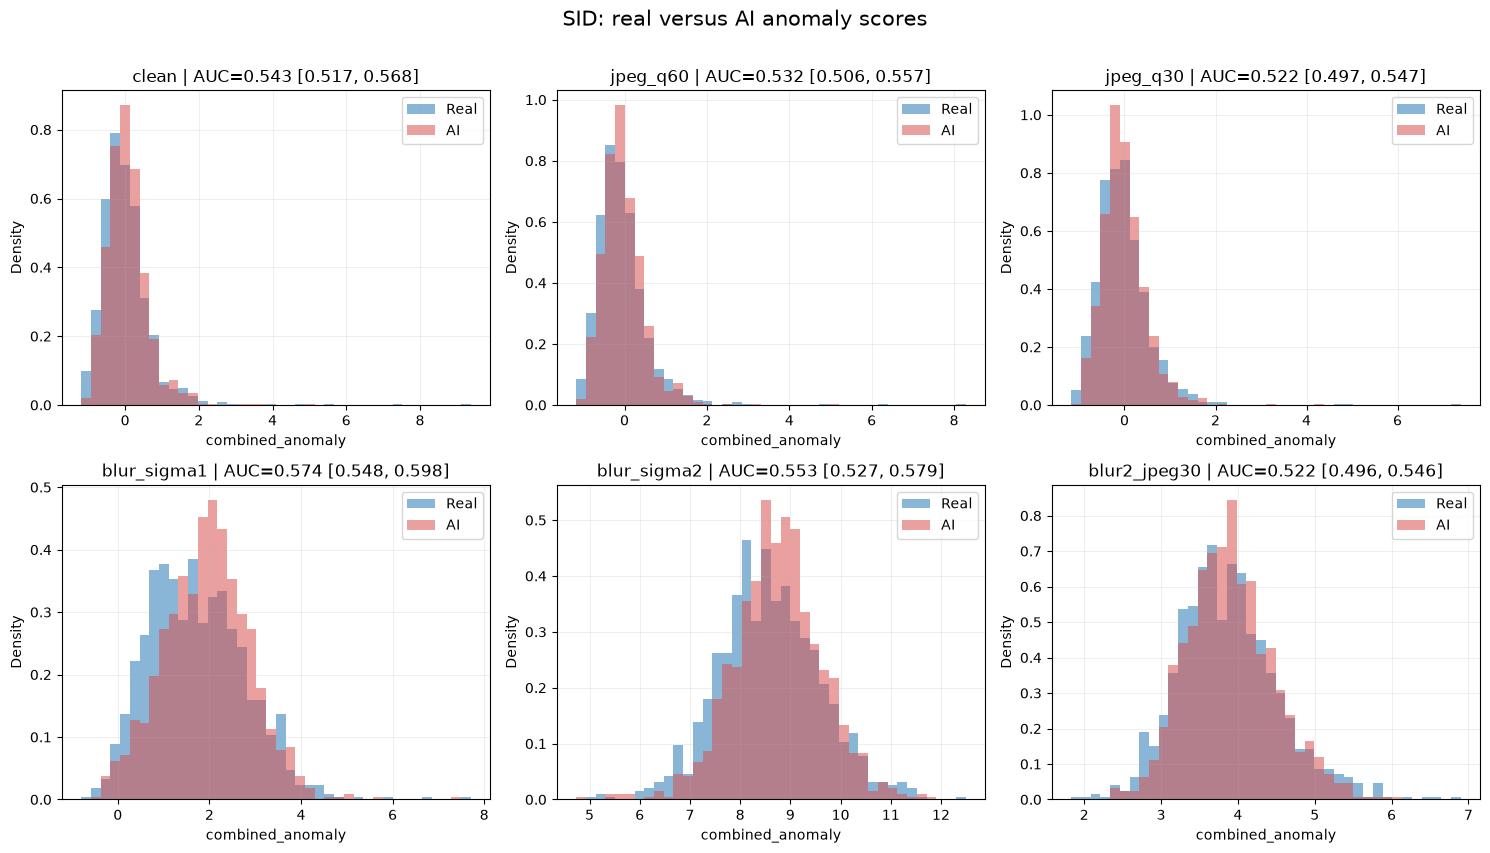

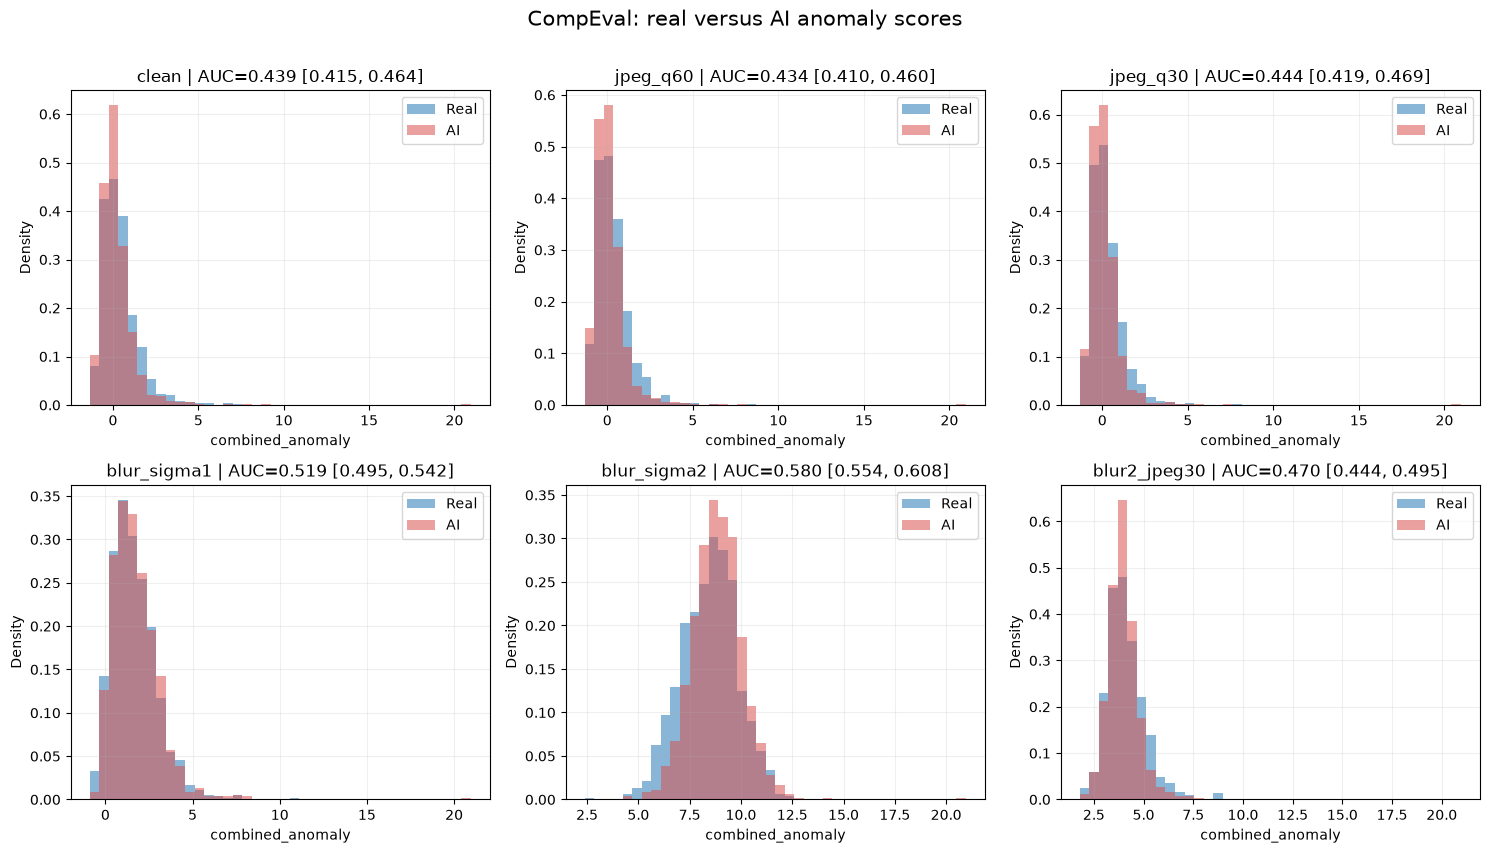

In [10]:
SCORE_TO_PLOT = "combined_anomaly"
HISTOGRAM_BINS = 40

for dataset_name in evaluation_sets:
    dataset_frame = all_scores[
        all_scores["dataset"] == dataset_name
    ]

    columns = 3
    rows = math.ceil(len(VARIANTS) / columns)
    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(15, 4.2 * rows),
        squeeze=False,
    )
    axes = axes.ravel()

    for axis, variant in zip(axes, VARIANTS):
        group = dataset_frame[
            dataset_frame["variant"] == variant
        ]
        real_values = group.loc[
            group["label"] == 0,
            SCORE_TO_PLOT,
        ].to_numpy()
        ai_values = group.loc[
            group["label"] == 1,
            SCORE_TO_PLOT,
        ].to_numpy()

        combined_values = np.concatenate(
            [real_values, ai_values]
        )
        bin_edges = np.histogram_bin_edges(
            combined_values,
            bins=HISTOGRAM_BINS,
        )

        axis.hist(
            real_values,
            bins=bin_edges,
            density=True,
            alpha=0.55,
            label="Real",
            color="#2878B5",
        )
        axis.hist(
            ai_values,
            bins=bin_edges,
            density=True,
            alpha=0.55,
            label="AI",
            color="#D9534F",
        )

        auc_row = auc_summary[
            (auc_summary["dataset"] == dataset_name)
            & (auc_summary["variant"] == variant)
            & (auc_summary["score"] == SCORE_TO_PLOT)
        ].iloc[0]

        axis.set_title(
            f"{variant} | AUC={auc_row['auc']:.3f} "
            f"[{auc_row['ci_low']:.3f}, {auc_row['ci_high']:.3f}]"
        )
        axis.set_xlabel(SCORE_TO_PLOT)
        axis.set_ylabel("Density")
        axis.grid(alpha=0.2)
        axis.legend()

    for axis in axes[len(VARIANTS):]:
        axis.set_visible(False)

    fig.suptitle(
        f"{dataset_name}: real versus AI anomaly scores",
        fontsize=15,
        y=1.01,
    )
    fig.tight_layout()
    figure_path = (
        OUTPUT_DIR
        / f"{dataset_name.lower()}_{SCORE_TO_PLOT}_histograms.png"
    )
    fig.savefig(
        figure_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

## Compare all three scores across degradation

A useful frequency cue should be above chance in the fixed direction, reasonably consistent between SID and CompEval, and resistant to the degradation shift. A high clean SID AUC with near-chance CompEval AUC more likely indicates dataset/content anomaly than generator-invariant evidence.

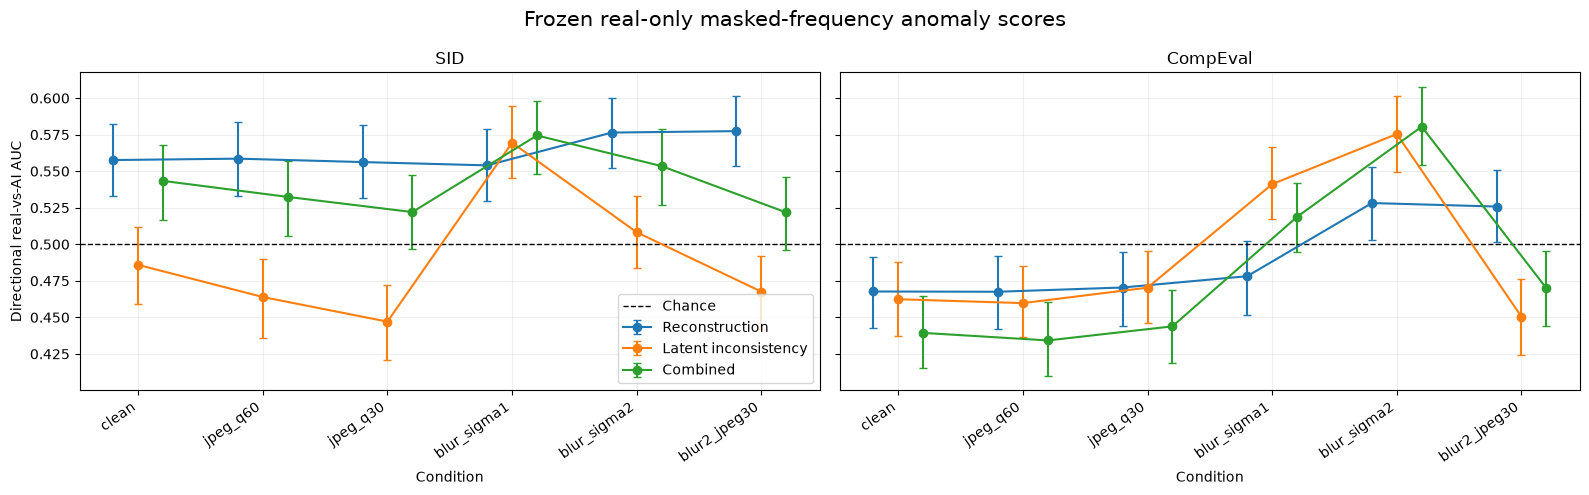

In [11]:
score_labels = {
    "reconstruction_error": "Reconstruction",
    "latent_anomaly": "Latent inconsistency",
    "combined_anomaly": "Combined",
}

fig, axes = plt.subplots(
    1,
    len(evaluation_sets),
    figsize=(16, 5),
    sharey=True,
)
axes = np.atleast_1d(axes)

x = np.arange(len(VARIANTS))
offsets = np.linspace(-0.20, 0.20, len(PLOT_SCORE_COLUMNS))

for axis, dataset_name in zip(axes, evaluation_sets):
    for offset, score_name in zip(offsets, PLOT_SCORE_COLUMNS):
        rows = (
            auc_summary[
                (auc_summary["dataset"] == dataset_name)
                & (auc_summary["score"] == score_name)
            ]
            .set_index("variant")
            .loc[VARIANTS]
        )

        y = rows["auc"].to_numpy()
        y_error = np.vstack(
            [
                y - rows["ci_low"].to_numpy(),
                rows["ci_high"].to_numpy() - y,
            ]
        )

        axis.errorbar(
            x + offset,
            y,
            yerr=y_error,
            marker="o",
            capsize=3,
            linewidth=1.5,
            label=score_labels[score_name],
        )

    axis.axhline(
        0.5,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Chance" if dataset_name == "SID" else None,
    )
    axis.set_xticks(x)
    axis.set_xticklabels(
        VARIANTS,
        rotation=35,
        ha="right",
    )
    axis.set_title(dataset_name)
    axis.set_xlabel("Condition")
    axis.grid(alpha=0.2)

axes[0].set_ylabel("Directional real-vs-AI AUC")
axes[0].legend(loc="best")
fig.suptitle(
    "Frozen real-only masked-frequency anomaly scores",
    fontsize=15,
)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "auc_by_condition.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## Conservative go/no-go diagnostic

The thresholds below are engineering heuristics, not statistical laws. The default asks for:

- combined clean AUC of at least 0.60,
- clean lower confidence bound above 0.50, and
- worst degraded point AUC of at least 0.55.

Inspect individual reconstruction and latent scores too. If one is consistently informative and the combined score dilutes it, a new combination weight must be fixed on a separate development set—not selected retrospectively on the reported test conditions.

In [ ]:
DECISION_SCORE = "combined_anomaly"
MIN_CLEAN_AUC = 0.60
MIN_CLEAN_CI_LOW = 0.50
MIN_WORST_DEGRADED_AUC = 0.55

decision_rows = []

for dataset_name in evaluation_sets:
    rows = auc_summary[
        (auc_summary["dataset"] == dataset_name)
        & (auc_summary["score"] == DECISION_SCORE)
    ].set_index("variant")

    clean = rows.loc["clean"]
    degraded = rows.loc[
        [variant for variant in VARIANTS if variant != "clean"]
    ]
    worst_variant = degraded["auc"].idxmin()
    worst_auc = float(degraded.loc[worst_variant, "auc"])

    passes = (
        clean["auc"] >= MIN_CLEAN_AUC
        and clean["ci_low"] > MIN_CLEAN_CI_LOW
        and worst_auc >= MIN_WORST_DEGRADED_AUC
    )

    decision_rows.append(
        {
            "dataset": dataset_name,
            "clean_auc": float(clean["auc"]),
            "clean_ci_low": float(clean["ci_low"]),
            "worst_degraded_variant": worst_variant,
            "worst_degraded_auc": worst_auc,
            "pilot_decision": (
                "GO: justify a fuller classifier experiment"
                if passes
                else "NO-GO: cue is not yet stable enough"
            ),
        }
    )

decision_table = pd.DataFrame(decision_rows)
decision_table.to_csv(
    OUTPUT_DIR / "go_no_go_summary.csv",
    index=False,
)
decision_table

## How to interpret the result

- AUC near 0.5 with a confidence interval spanning 0.5 means this anomaly score has little demonstrated class information.
- Reconstruction AUC above 0.5 but latent AUC near 0.5 means the cross-band prediction error helps, while the chosen pooled representation does not.
- Latent AUC above 0.5 but reconstruction AUC near 0.5 means consistency is more useful than pixelwise spectral reconstruction.
- Strong SID but weak CompEval performance suggests domain/content mismatch, not a broadly generator-invariant cue.
- A consistent AUC below 0.5 means AI images receive lower anomaly scores. Do not flip the score after looking at the test labels; establish direction on a separate labeled development set if you investigate it.
- Degradation can shift both real and AI scores. AUC remains useful because it measures ranking, but overlapping histograms reveal whether the effect is practically small.
- Passing this pilot supports trying a stronger encoder, multi-cutoff masking, or a classifier using frozen multi-layer similarity features. Failing it rejects this particular pilot configuration—not all frequency-domain learning.

For a fair next step, decide the architecture and score direction using SID plus a designated development set, then evaluate DALL-E3 once.